# 2.3.4 R2R workflow Tests with response models

This test will examine how [response models](https://r2r-docs.sciphi.ai/cookbooks/structured-output) work with R2R for generating structured output

## Method

Each prompt will ask roughly the same question about a VDBI project with minor modifications to examine how these modifications affect the output.
In this case, prompts will ask questions about the NEO project's "research actions" and the outpout format target is JSON (since it is a widely supported output format by model).

The test configuration (including, prompts, prompt descriptions, prompt templates, and output formats) are configured in the file [./test-data/configs/workflow_2.3.4_config.json](test-data/configs/workflow_2.3.4_config.json).

Test results are output to [test-data/private/output/r2r-tests/2.3.4/](./test-data/private/output/r2r-tests/2.3.4/) by default.

### Prompts <!-- omit in toc -->

The following parameters are changed between prompts

1. Asking for the prompt to be formatted (e.g., in JSON)
2. The response format types are changed (e.g., lists, objects). Additionally, in the case of JSON objects

   1. Object hierarchies
   2. Object keys

3. Define research actions as an object

   - prompt:
     > What are the proposed research actions of the NEO project?
   - format:

     ```json
     "response_format": {
       "type": "json_object"
     }
     ```

4. Define research actions as a string

   - prompt:
     > What are the proposed research actions of the NEO project?
   - format:

     ```json
     "response_format": {
       "type": "json_schema",
       "json_schema": {
         "schema": {
           "type": "array",
           "items": {
             "type": "string"
           }
         }
       }
     }
     ```

### Prompt Template <!-- omit in toc -->

A prompt template is also provided to contextualize each prompt.

```markdown
## Task

Answer the query given immediately below given the context which follows later. Output your response in JSON.

### Query

{query}

### Context

{context}
```



## Run test

### Dependencies

First make sure you have installed [the basic dependencies](./r2r-tests.md#dependencies).

This test uses a fully dockerized vector store and ollama instance.

Follow [these instructions](https://hub.docker.com/r/ollama/ollama) as necessary if you would like to enable NVIDIA or AMD access to ollama.

Note that you do not have to run ollama as a docker container from these instructions. A docker compose is provided that will run ollama.

### Setup

Then setup and start local services.


In [20]:
# start ollama and pgvector
!docker compose -f src/docker-compose.yml up vector_store -d

[+] Running 0/1
 ⠋ Container src-vector_store-1  Startin...                                0.1s 
[+] Running 0/1
 ⠙ Container src-vector_store-1  Startin...                                0.2s 
[+] Running 0/1
 ⠹ Container src-vector_store-1  Startin...                                0.3s 
[+] Running 0/1
 ⠸ Container src-vector_store-1  Startin...                                0.4s 
[+] Running 0/1
 ⠼ Container src-vector_store-1  Startin...                                0.5s 
[+] Running 0/1
 ⠴ Container src-vector_store-1  Startin...                                0.6s 
[+] Running 0/1
 ⠦ Container src-vector_store-1  Startin...                                0.7s 
[+] Running 0/1
 ⠧ Container src-vector_store-1  Startin...                                0.8s 
[+] Running 0/1
 ⠇ Container src-vector_store-1  Startin...                                0.9s 
[+] Running 0/1
 ⠏ Container src-vector_store-1  Startin...                                1.0s 
[+] Running 1/1
 ✔ Container s

In [ ]:
# ollama setup
!docker compose -f src/docker-compose.yml exec ollama ollama pull llama3.1
!docker compose -f src/docker-compose.yml cp test-data/modelfiles/r2r_test2321 ollama:/tmp/Modelfile
!docker compose -f src/docker-compose.yml exec ollama ollama create llama3.1 -f /tmp/Modelfile
!docker compose -f src/docker-compose.yml exec ollama ollama pull mxbai-embed-large

In [4]:
# python setup
!uv sync
!source .venv/bin/activate

Resolved 265 packages in 11ms
⠙ Preparing packages... (0/15)                                                  
⠙ Preparing packages... (0/15)-------------     0 B/9.53 KiB            
⠙ Preparing packages... (0/15)--------- 9.53 KiB/9.53 KiB           
⠙ Preparing packages... (0/15)--------- 9.53 KiB/9.53 KiB           
shellingham          ------------------------------ 9.53 KiB/9.53 KiB
⠙ Preparing packages... (0/15)-------------     0 B/9.75 KiB            
shellingham          ------------------------------ 9.53 KiB/9.53 KiB
⠙ Preparing packages... (0/15)--------- 9.75 KiB/9.75 KiB           
shellingham          ------------------------------ 9.53 KiB/9.53 KiB
⠙ Preparing packages... (0/15)--------- 9.75 KiB/9.75 KiB           
shellingham          ------------------------------ 9.53 KiB/9.53 KiB
⠙ Preparing packages... (0/15)--------- 9.75 KiB/9.75 KiB           
shellingham          ------------------------------ 9.53 KiB/9.53 KiB
mdurl                ---------------------------

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# r2r setup
os.environ['R2R_CONFIG_PATH'] = os.path.join(os.path.abspath(""), 'test-data', 'configs', 'r2r_config.toml')
!echo $R2R_CONFIG_PATH

# start r2r server
os.system("python -m r2r.serve >> r2r.log 2>&1 &")

/home/diego/Git/PEPR-VDBI/data-integration/test-data/configs/r2r_config.toml


0

You can test if the R2R server is running by going to [http://localhost:7272/v3/health](http://localhost:7272/v3/health)


### Run the test

> ⚠️Note⚠️
>
> Input files may not be publicly available. If you are missing input data. Please reach out to the repository admin or the "Responsable de la veille" of the PEPR VDBI Governance and Animation team.

> ℹ️TIPℹ️
>
> To see the workflow documentation run
>
> ```bash
> python src/workflow_test.py -h
> ```
>
> If using the LIRIS Pagoda3 Ollama service (or another API with authentication), use the `-t` flag as follows and replace `[BEARER TOKEN]` with a valid bearer token
>
> ```bash
> python src/workflow_test.py -m r2r -t [BEARER TOKEN] test-data/configs/workflow_2.3.4_config.json
> ```
>
> Also, note the warning about proxies in [section 2.3.3 - Run](./r2r-tests.md#233-run) if you have trouble connecting to Pagoda3


In [ ]:
!python src/workflow_test.py -m r2r test-data/configs/workflow_2.3.4_config.json -d

## Results

### Compile the test results

In [33]:
test_output_path = "test-data/private/output/r2r-tests/2.3.4/"
prompt_responses = []
chunk_search_results = []
config = {}

with open("test-data/configs/workflow_2.3.4_config.json") as file:
    config = json.load(file)

for root, directories, files in os.walk(test_output_path):
    for directory in directories:
        response_file_path = os.path.join(root, directory, "response.json")
        prompt_id = directory.split("_")[-1]
        if os.path.exists(response_file_path):
            with open(response_file_path, "r") as response_file:
                response = json.load(response_file)
                response["prompt_id"] = prompt_id
                for key, value in response.get("metadata", {}).items():
                    response[key] = value
                for key, value in response.get("usage", {}).items():
                    response[key] = value
                prompt_responses.append(response)
                for result in response.get("search_results", {}).get(
                    "chunk_search_results", []
                ):
                    result["prompt_id"] = prompt_id
                    for key, value in result.get("metadata", {}).items():
                        result[key] = value
                    chunk_search_results.append(result)

print(f"Total prompt responses: {len(prompt_responses)}")
print(f"Total chunks: {len(chunk_search_results)}")

chunks_counts = {}
for chunk in chunk_search_results:
    chunk_order = chunk.get("chunk_order")
    if chunk_order in chunks_counts:
        chunks_counts[chunk_order]["count"] += 1
        chunks_counts[chunk_order]["scores"].append(chunk.get("score"))
    else:
        chunks_counts[chunk_order] = {
            "count": 0,
            "scores": [chunk.get("score")],
            "text": chunk.get("text")[0:75].replace("\n", "\\n"),
        }

Total prompt responses: 32
Total chunks: 320


### Prompt descriptions

In [34]:
id = 0
print("prompt\tdescription")
for prompt_config in config.get("prompts", []):
    print(f"{id}\t{prompt_config.get("description")}")
    id += 1

prompt	description
0	A basic prompt about research actions as an object
1	A basic prompt about research actions as an object with a request for JSON structure
2	A basic prompt about research actions as a structured list
3	A basic prompt about research actions as a structured list with a request for JSON structure
4	A basic prompt about research actions as an object with a structured list
5	Does a description change the output?
6	Basic prompt variation
7	Basic prompt variation
8	Basic prompt variation
9	Basic prompt variation with structured response
10	Basic prompt variation with structured response
11	Basic prompt variation with structured response
12	Prompt on two criteria: research actions and solutions with an open response format
13	Prompt on two criteria: research actions and solutions with a structured response format (two lists)
14	Prompt on two criteria: research actions and solutions with a structured response format (list of objects)
15	Prompt on two criteria: research actio

### Chunk results

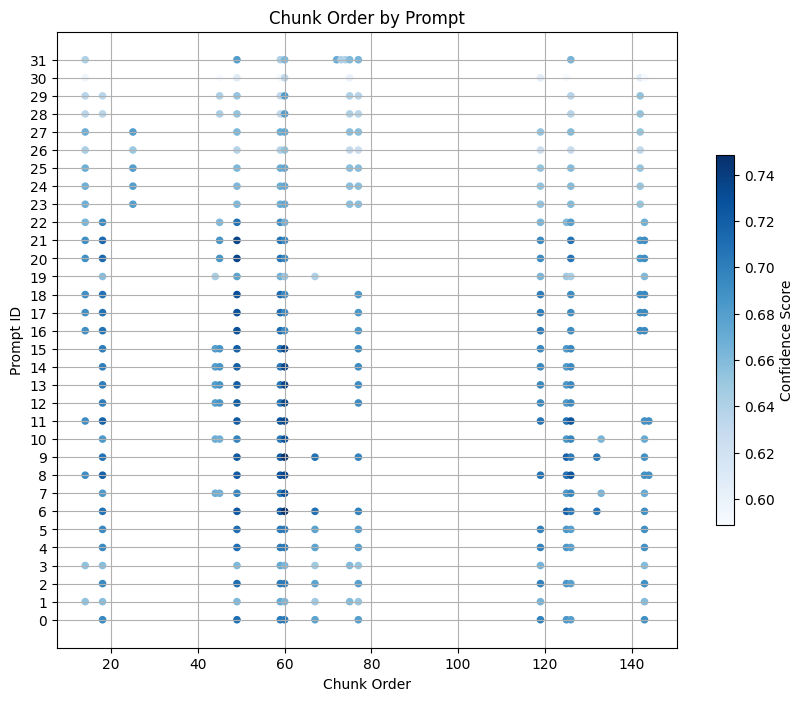

In [35]:
fig, ax = plt.subplots()
x = []
y = []
z = []

for result in sorted(
    chunk_search_results,
    key=lambda x: (int(x.get("prompt_id")), int(x.get("chunk_order"))),
):
    x.append(result.get("chunk_order"))
    y.append(result.get("prompt_id"))
    z.append(result.get("score"))

plt.title("Chunk Order by Prompt")
fig.set_figwidth(10)
fig.set_figheight(8)
ax.set_ylabel("Prompt ID")
ax.set_xlabel("Chunk Order")

fig.colorbar(
    ax.scatter(
        x,
        y,
        20,
        z,
        cmap="Blues",
    ),
    ax=ax,
    shrink=0.6,
    label="Confidence Score",
)

ax.grid(True)

#### Chunks by occurrences

In [36]:
for chunk, value in sorted(chunks_counts.items(), key=lambda x: x[1]["count"], reverse=True):
    print(
        f"chunk: {chunk}\tcount: {value["count"]}\ttext: {value["text"]}..."
    )

chunk: 60	count: 31	text: scientists is a real challenge that we must overcome collectively if we are...
chunk: 59	count: 31	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\n2.Detailed p...
chunk: 49	count: 31	text: and building new knowledge on an ongoing basis...". (Bier, 2010). This invo...
chunk: 126	count: 28	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\nFigure 2 Gan...
chunk: 119	count: 24	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\nMilestones (...
chunk: 18	count: 24	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\nRésumé du pr...
chunk: 77	count: 22	text: end-users  (stakeholders  and  urban  planners).  These  strategic  activit...
chunk: 143	count: 19	text: with the other PEPR projects, thanks to the active national involvement of ...
chunk: 14	count: 18	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\npasse par (i...
chunk: 125	count: 16	text: - WP4

#### Chunks by average confidence score

In [37]:
chunks_average_score = [
    (chunk, np.average(value["scores"]), len(value["scores"]), value["text"]) for chunk, value in chunks_counts.items()
]

for chunk, average, count, text in sorted(chunks_average_score, key=lambda x: x[1], reverse=True):
    print(
        f"chunk: {chunk}\taverage score: {average} / {count}\ttext: {text}..."
    )

chunk: 132	average score: 0.7058929941273329 / 2	text: regard to knowledge transfer activities. Since data may be protected by sev...
chunk: 60	average score: 0.6969081242899156 / 32	text: scientists is a real challenge that we must overcome collectively if we are...
chunk: 49	average score: 0.6954873229909098 / 32	text: and building new knowledge on an ongoing basis...". (Bier, 2010). This invo...
chunk: 18	average score: 0.691353238862391 / 25	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\nRésumé du pr...
chunk: 144	average score: 0.689859221636481 / 2	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\n5.Funding ju...
chunk: 59	average score: 0.6876729863877993 / 32	text: PEPR VBDI\nAPPEL À PROJETS\n2023DOCUMENT PRÉSENTATION PROJET\nNEO\n2.Detailed p...
chunk: 125	average score: 0.6819802842870678 / 17	text: - WP4 M Carmes (Le Cnam) , specialist in environmental and innovation socio...
chunk: 126	average score: 0.6811285290137283 / 29	t

# Analysis

The following observations have been made after reviewing the results of the test.

Each prompt is refered to by its (0 indexed) position in the configuration.
I.e., the first prompt executed is refered to as prompt **0**. It's results are located in the configured output folder location suffixed with the prompt number: [test-data/private/output/r2r-tests/2.3.4/2.3.4_0/](./test-data/private/output/r2r-tests/2.3.4/2.3.4_0/).

Observations are numbered as well.

1. Prompt 3

- This prompt asks for a simple json array using the following configuration:

  ```json
  {
    "prompt": "What are the proposed research actions of the NEO project? Structure your response in JSON.",
    "description": "A basic prompt about research actions as a structured list with a request for JSON structure",
    "rag_generation_config": {
      "response_format": {
        "type": "json_schema",
        "json_schema": {
          "schema": {
            "type": "array",
            "items": {
              "type": "string"
            }
          }
        }
      }
    }
  }
  ```

- The output seems to represent sentences (verbatim citations even) from the following chunks:

  3rd, 4th, and 5th retrieved chunks (chunks `119`, `60`, `49`) in the input document.

  ```json
  [
    "researchActions",
    "Milestones (M) -",
    "1. Mobilisation of the FabLab networks and sharing of a common roadmap to answer the issues raised by each use case (6m).",
    "2. Co-Building of training module between researchers involved in the UC and the in the WP4 (Year 4).",
    "3. The analysis of the data collected by the different tools deployed by WP2., so that the researchers could be able to compare the different use cases and to discuss the results with the different stakeholders (Year 4).",
    "Deliveries (D) - D4.1 : Training modules on the three UC; D4.2 : Reflective scientific report on Neo project and urban futures in the context of ecological crises (combining the diversity of stakeholders); D4.3 : Prototyping of data services based on Observil and Terra Forma databases, instruments (sensors); D4.4 : Documentation for replication of work on sensors and data; D4.5 : Participatory",
    "scientists is a real challenge that we must overcome collectively if we are to better co-construct the city of today and tomorrow. Neo proposes an original approach combining the human and social sciences and the environmental sciences, based on capitalising on data that already exists and is in the process of being structured, and on new data produced in use cases and as part of participative experiments that give the citizen a place.",
    "The aim of the project is to enable professionals and decision-makers who play a role in urban planning, as well as citizens who are more or less aware of the ecological transition of our cities, to gain a better understanding of their environmental capital and to optimize it through appropriate urban planning, in order to improve the well-being of residents.",
    "Innovative measures are envisaged to optimize water management in private homes and public spaces, and to co-construct public spaces in",
    "and building new knowledge on an ongoing basis...",
    "This involves (i) producing 'digital services' associated with the environmental data acquired (prototyping applications, designing interfaces for using the data for expert and non-expert audiences), (ii) stimulating so-called citizen metrology (Carmes et al., 2023) and co-production of knowledge with urban managers and civil society.",
    "This arrangement of the NEO project, aimed at hybridizing the knowledge and viewpoints of different user stakeholders, will make it possible to test the replicability of transfer methodologies in the different urban areas of our network of partners."
  ]
  ```

#### Observation: Asking for a JSON structure in the prompt may yield more detailed results

Tests 0-3 repeat the same same prompt modifying simply the type of response format and asking for JSON in the prompt.

> [!NOTE]
> A `json_object` response format type simply requires the response be formatted in JSON with no additional schematic constraints.
>
> A `json_schema` response format type defines a JSON schema to which the response must conform.

| #   | Prompt                                                                                        | Response format type |
| --- | --------------------------------------------------------------------------------------------- | -------------------- |
| 0   | "What are the proposed research actions of the NEO project?"                                  | `json_object`        |
| 1   | "What are the proposed research actions of the NEO project? Structure your response in JSON." | `json_object`        |
| 2   | "What are the proposed research actions of the NEO project?"                                  | `json_schema`        |
| 3   | "What are the proposed research actions of the NEO project? Structure your response in JSON." | `json_schema`        |

Both prompts specifying a JSON format had more detailed and usable response:

- Response 0

  ```json
  {
    "researchActions": [
      "producing digital services associated with environmental data acquired",
      "stimulating citizen metrology and co-production of knowledge with urban managers and civil society"
    ]
  }
  ```

- Response 1

  ```json
  {
    "researchActions": [
      {
        "action": "Mobilisation of the FabLab networks and sharing of a common roadmap",
        "description": "6 months"
      },
      {
        "action": "Co-Building of training module between researchers involved in the UC and WP4",
        "year": "Year 4"
      },
      {
        "action": "Analysis of data collected by different tools deployed by WP2",
        "year": "Year 4"
      }
    ],
    "deliverables": [
      {
        "deliverable": "Training modules on three Use Cases",
        "description": "D4.1"
      },
      {
        "deliverable": "Reflective scientific report on Neo project and urban futures in the context of ecological crises",
        "description": "D4.2"
      },
      {
        "deliverable": "Prototyping of data services based on Observil and Terra Forma databases, instruments (sensors)",
        "description": "D4.3"
      },
      {
        "deliverable": "Documentation for replication of work on sensors and data",
        "description": "D4.4"
      },
      {
        "deliverable": "Participatory approach to co-production of knowledge with urban managers and civil society",
        "description": "D4.5"
      }
    ],
    "applicationAreas": [
      {
        "city": "Toulouse",
        "region": "Rennes",
        "potentialOtherCities": ["Nantes"]
      }
    ],
    "partners": [
      {
        "partner": "Institut d'Am\u00e9nagement et d'Urbanisme de Rennes",
        "contribution": "expertise and know-how"
      },
      {
        "partner": "Observil national observation network",
        "contribution": "expertise and know-how"
      }
    ]
  }
  ```

- Response 2

  ```json
  []
  ```

- Response 3

  ```json
  [
    "researchActions",
    "Milestones (M) -",
    "1. Mobilisation of the FabLab networks and sharing of a common roadmap to answer the issues raised by each use case (6m).",
    "2. Co-Building of training module between researchers involved in the UC and the in the WP4 (Year 4).",
    "3. The analysis of the data collected by the different tools deployed by WP2., so that the researchers could be able to compare the different use cases and to discuss the results with the different stakeholders (Year 4).",
    "Deliveries (D) - D4.1 : Training modules on the three UC; D4.2 : Reflective scientific report on Neo project and urban futures in the context of ecological crises (combining the diversity of stakeholders); D4.3 : Prototyping of data services based on Observil and Terra Forma databases, instruments (sensors); D4.4 : Documentation for replication of work on sensors and data; D4.5 : Participatory",
    "scientists is a real challenge that we must overcome collectively if we are to better co-construct the city of today and tomorrow. Neo proposes an original approach combining the human and social sciences and the environmental sciences, based on capitalising on data that already exists and is in the process of being structured, and on new data produced in use cases and as part of participative experiments that give the citizen a place.",
    "The aim of the project is to enable professionals and decision-makers who play a role in urban planning, as well as citizens who are more or less aware of the ecological transition of our cities, to gain a better understanding of their environmental capital and to optimize it through appropriate urban planning, in order to improve the well-being of residents.",
    "Innovative measures are envisaged to optimize water management in private homes and public spaces, and to co-construct public spaces in",
    "and building new knowledge on an ongoing basis...",
    "This involves (i) producing 'digital services' associated with the environmental data acquired (prototyping applications, designing interfaces for using the data for expert and non-expert audiences), (ii) stimulating so-called citizen metrology (Carmes et al., 2023) and co-production of knowledge with urban managers and civil society.",
    "This arrangement of the NEO project, aimed at hybridizing the knowledge and viewpoints of different user stakeholders, will make it possible to test the replicability of transfer methodologies in the different urban areas of our network of partners."
  ]
  ```

![test 2.3.4_graph_result](img/2.3.4_graph_result.png)
